# Grupp 4: Batch size och epoker

Ett grupparbete om djupinlärningens träningsprocess, med *Fashion MNIST* som dataset.

Vi undersöker tiden för träningen, hur stabil den är och *accuracy* under olika inställningar.

## 1. Importer

In [1]:
# Importerar tid, numeriska, grafiska och metodiska bibliotek (tensorflow, keras)
import time
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Input

# Sätter slump seed
tf.keras.utils.set_random_seed(42)

## 2. Ladda och anpassa *Fashion MNIST*

Datasetet har 10 typer (*klasser*) av kläder.

Vi ser över hur många bilder finns och hur fördelningen av klasser är, sen skalar vi och skapar validering-set.

X_train_raw antal & storlek: (60000, 28, 28)
X_test_raw antal & storlek: (10000, 28, 28)
Fashion MNIST antal bilder: 70000

Här är bilder från train:


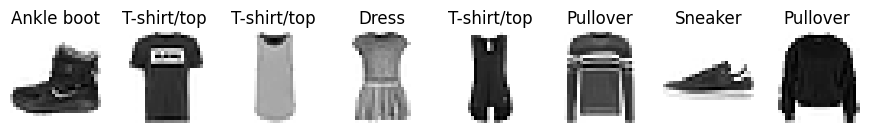

Här är klassförelning i träningsdata:


,Klass,Antal,Andel i procent
0,T-shirt/top,6000,10.0
1,Trouser,6000,10.0
2,Pullover,6000,10.0
3,Dress,6000,10.0
4,Coat,6000,10.0
5,Sandal,6000,10.0
6,Shirt,6000,10.0
7,Sneaker,6000,10.0
8,Bag,6000,10.0
9,Ankle boot,6000,10.0


In [2]:
# Ladda bilder
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

# Klassnamnen (0-9)
class_names = ["T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]
print("X_train_raw antal & storlek:", X_train_raw.shape)
print("X_test_raw antal & storlek:", X_test_raw.shape)
print("Fashion MNIST antal bilder:", X_train_raw.shape[0]+X_test_raw.shape[0])


# Visa bilder från train
fig, ax = plt.subplots(1, 8, figsize=(11, 2))
for i in range(8):
    ax[i].imshow(X_train_raw[i], cmap="binary")
    ax[i].set_title(class_names[y_train_raw[i]])
    ax[i].axis("off")
print("\nHär är bilder från train:")
plt.show()


# Räkna ut fördelning med numpy
unique = np.unique(y_train_raw)
counts = [np.sum(y_train_raw == i) for i in unique]

# Gör och visa en DataFrame utav fördelningen
classes_df = pd.DataFrame({
    "Klass": class_names,
    "Antal": counts,
    "Andel i procent": np.array(counts) / len(y_train_raw) * 100
})
print("Här är klassförelning i träningsdata:")
classes_df

<font size=5>**Anpassning och validering-split:**</font>

1. Pixlar har värde mellan *[0,255]* så vi normaliserar (*skalar*) genom division och får *[0,1]*.
2. Vi formar om bildernas *28x28* till *28x28x1* som är enkel gråskala-kanal för CNN (*Convolutional Neural Network*).
3. Dela upp skalade `X_train` så vi får validering-set (storlek 10,000 som test-setet), med *stratify* från `y_train_raw`

In [3]:
# Normalisera med division, sätt typ float32
X_train = X_train_raw.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

# Expandera med gråskala kanal för CNN
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

# Dela upp för att få validering-set
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train_raw, test_size=10000, random_state=42, stratify=y_train_raw
)

print("X_train antal & storlek:", X_train.shape)
print("X_val antal & storlek:", X_val.shape)
print("X_test antal & storlek:", X_test.shape)

X_train antal & storlek: (50000, 28, 28, 1)
X_val antal & storlek: (10000, 28, 28, 1)
X_test antal & storlek: (10000, 28, 28, 1)


## 3. Funktion för CNN-modell

Med en funktion gör vi en CNN modell med input-storlek (*28x28*). Storlekarna 32, 64 och 128 neuroner som dolda lager (med *relu* som aktiveringsfunktion), och 10 klasserna som output-lager med `softmax` som aktiveringsfunktion (passar multiklass). *Convolutional* `Conv2D` lagren lär sig grafiska mönstren och `MaxPooling2D` zoomar in. `Dense` gör tolkningarna.

Vi kallar senare funktionen `model_maker` när vi ska passa modellen till träningsdata och göra prediktioner. Såhär får vi nya modeller till experimenten som inte tidigare tränats.

In [4]:
def model_maker(learning_rate=0.001): # Learning rate är inte vårat fokus så den förblir 0.001
    model = keras.Sequential([
        Input(shape=(28, 28, 1)),

        # Convolutional lager 1
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        # Convolutional lager 2
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Dense behöver platt input
        layers.Flatten(),
        layers.Dense(128, activation="relu"),

        # Output
        layers.Dense(10, activation="softmax")
    ])

    # Sparse_cat_crossent: för klasserna är integers & categorical crossentropy är för one-hot.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    return model

## 4. Funktion för epok & batch-tester

Använd CNN funktionen från *kap. 3* i en testfunktion så blir epoker och batcher enkla att göra nya modeller för.

Inspiration av funktioner från föreläsningar.

In [5]:
def test_function(name, epochs=10, batch_size=32): # 10 & 32 standard om ej annat anges i kallande
    print(f"\nKör experiment: {name}")
    print(f"epochs={epochs}, batch_size={batch_size}")

    model = model_maker()

    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )
    total_time = time.time() - start_time

    print(f"Träningstid: {total_time:.2f} sekunder")

    return history, total_time, model

def plot_history(histories, title):
    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    for name, history in histories.items():
        plt.plot(history.history['val_accuracy'], label=f"{name}")
    plt.title(f"{title} - Validation Accuracy")
    plt.xlabel("Epoch")
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    for name, history in histories.items():
        plt.plot(history.history['val_loss'], label=f"{name}")
    plt.title(f"{title} - Validation Loss")
    plt.xlabel("Epoch")
    plt.legend()

    plt.show()

## 5. Test av olika antal epoker

Här testar vi hur antalet epoker påverkar modellen.

En epok betyder att modellen går igenom hela träningsdatan en gång. Om vi tränar med fler epoker får modellen fler chanser att lära sig mönster i bilderna.

Vi testar 5, 10 och 20 epoker. Det gör vi för att jämföra kort träning, normal träning och längre träning.

För att testet ska bli rättvist håller vi batch size samma hela tiden. Här använder vi batch size 32.

In [6]:
# Testar olika antal epoker med samma batch size
# Vi håller batch size konstant för att bara undersöka hur epoker påverkar modellen
epoch_tests = [
    {"name": "5 epoker", "epochs": 5, "batch_size": 32},
    {"name": "10 epoker", "epochs": 10, "batch_size": 32},
    {"name": "20 epoker", "epochs": 20, "batch_size": 32}
]

# Här sparas historik, resultat och modeller från varje experiment
epoch_histories = {}
epoch_results = {}
epoch_models = {}

# Kör varje epok-test en gång
for test in epoch_tests:
    history, total_time, model = test_function(
        name=test["name"],
        epochs=test["epochs"],
        batch_size=test["batch_size"]
    )

    # Testar modellen på testdata efter träning
    test_loss, test_accuracy = model.evaluate(X_test, y_test_raw, verbose=0)

    # Sparar historiken så vi kan göra grafer senare
    epoch_histories[test["name"]] = history

    # Sparar modellen om vi vill använda den senare
    epoch_models[test["name"]] = model

    # Sparar sista värdena från träningen och testresultatet
    epoch_results[test["name"]] = {
        "Epoker": test["epochs"],
        "Batch size": test["batch_size"],
        "Train accuracy": history.history["accuracy"][-1],
        "Validation accuracy": history.history["val_accuracy"][-1],
        "Test accuracy": test_accuracy,
        "Train loss": history.history["loss"][-1],
        "Validation loss": history.history["val_loss"][-1],
        "Test loss": test_loss,
        "Träningstid sek": total_time
    }

# Gör resultaten till en tabell
epoch_results_df = pd.DataFrame(epoch_results).T
epoch_results_df


Kör experiment: 5 epoker
epochs=5, batch_size=32
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8494 - loss: 0.4193 - val_accuracy: 0.8959 - val_loss: 0.2925
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9017 - loss: 0.2717 - val_accuracy: 0.9072 - val_loss: 0.2605
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9177 - loss: 0.2250 - val_accuracy: 0.9095 - val_loss: 0.2495
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9309 - loss: 0.1889 - val_accuracy: 0.9125 - val_loss: 0.2400
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9417 - loss: 0.1584 - val_accuracy: 0.9168 - val_loss: 0.2389
Träningstid: 95.61 sekunder

Kör experiment: 10 epoker
epochs=10, batch_size=32
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8510 - loss: 0.4180 - val_accuracy: 0.8931 - val_loss: 0.2935
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9000 - loss: 

,Epoker,Batch size,Train accuracy,Validation accuracy,Test accuracy,Train loss,Validation loss,Test loss,Träningstid sek
5 epoker,5.0,32.0,0.94172,0.9168,0.9077,0.158387,0.238879,0.262186,95.606988
10 epoker,10.0,32.0,0.97878,0.9066,0.9039,0.059890,0.388281,0.416729,167.734225
20 epoker,20.0,32.0,0.99012,0.9121,0.9054,0.027095,0.520204,0.588464,391.945926


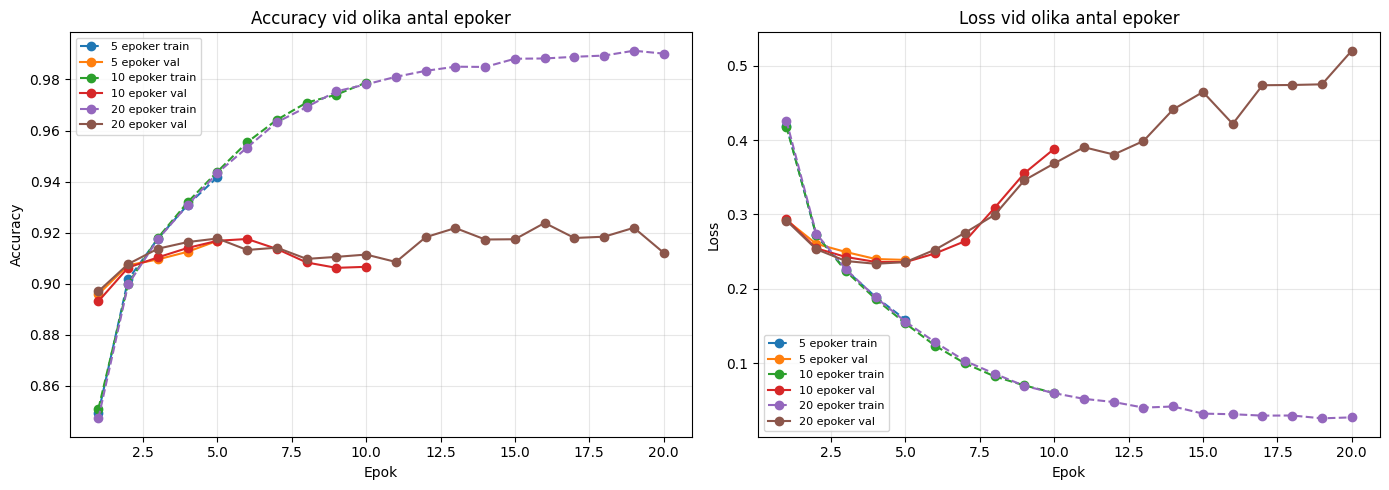

In [7]:
# Ritar grafer för epok-experimenten
# Vi visar både training och validation för att kunna se overfitting

plt.figure(figsize=(14, 5))

# Accuracy-graf
plt.subplot(1, 2, 1)

for name, history in epoch_histories.items():
    epochs_range = range(1, len(history.history["accuracy"]) + 1)

    plt.plot(
        epochs_range,
        history.history["accuracy"],
        linestyle="--",
        marker="o",
        label=f"{name} train"
    )

    plt.plot(
        epochs_range,
        history.history["val_accuracy"],
        marker="o",
        label=f"{name} val"
    )

plt.title("Accuracy vid olika antal epoker")
plt.xlabel("Epok")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)

# Loss-graf
plt.subplot(1, 2, 2)

for name, history in epoch_histories.items():
    epochs_range = range(1, len(history.history["loss"]) + 1)

    plt.plot(
        epochs_range,
        history.history["loss"],
        linestyle="--",
        marker="o",
        label=f"{name} train"
    )

    plt.plot(
        epochs_range,
        history.history["val_loss"],
        marker="o",
        label=f"{name} val"
    )

plt.title("Loss vid olika antal epoker")
plt.xlabel("Epok")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Kommentar till grafen

Grafen visar både training och validation eftersom vi vill se om modellen börjar overfitta.

I accuracy-grafen ser vi att training accuracy fortsätter öka när modellen tränas fler epoker. Validation accuracy förbättras först, men planar sedan ut.

I loss-grafen ser vi att training loss fortsätter minska, medan validation loss börjar öka efter några epoker. Det betyder att modellen blir bättre på träningsdatan, men inte bättre på valideringsdatan.

Detta är ett tecken på overfitting.

### Tolkning av resultatet

Resultatet visar att fler epoker inte automatiskt ger en bättre modell.

Modellen med fler epoker får högre training accuracy, men validation loss ökar. Det betyder att modellen börjar anpassa sig för mycket efter träningsdatan.

I vårt test ser vi tydliga tecken på overfitting vid fler epoker.. Ett lägre antal epoker kan vara bättre om validation accuracy är stabil och validation loss inte ökar lika mycket.

## 6. Test av batch sizes


Kör experiment: Batch_32
epochs=5, batch_size=32
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8480 - loss: 0.4239 - val_accuracy: 0.8941 - val_loss: 0.2968
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9010 - loss: 0.2739 - val_accuracy: 0.9073 - val_loss: 0.2586
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9183 - loss: 0.2243 - val_accuracy: 0.9130 - val_loss: 0.2388
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9314 - loss: 0.1879 - val_accuracy: 0.9186 - val_loss: 0.2317
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9435 - loss: 0.1554 - val_accuracy: 0.9199 - val_loss: 0.2311
Träningstid: 90.82 sekunder

Kör experiment: Batch_64
epochs=5, batch_size=64
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.8365 - loss: 0.4581 - val_accuracy: 0.8874 - val_loss: 0.3221
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8934 - loss: 0.2945 -

,Modell,Validation accuracy,Validation loss,Träningstid (sek)
0,Batch_32,0.9199,0.2311,90.8214
1,Batch_64,0.9154,0.2355,61.4813
2,Batch_128,0.9121,0.2424,54.1380


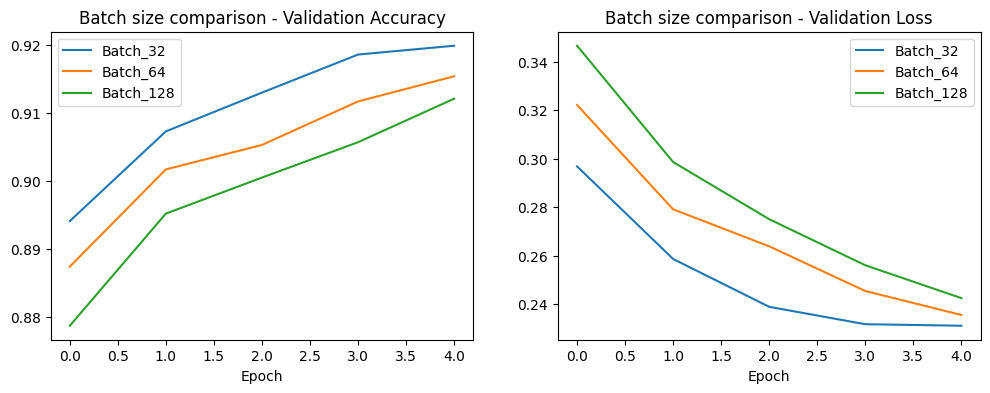

In [8]:
# dictionaries för history, tid och modell
histories = {}
times = {}
models = {}

# Testar batch-size på 32
history_32, time_32, model_32 = test_function(
    "Batch_32",
    epochs=5,
    batch_size=32
)

histories["Batch_32"] = history_32
times["Batch_32"] = time_32
models["Batch_32"] = model_32


# Testar batch-size på 64
history_64, time_64, model_64 = test_function(
    "Batch_64",
    epochs=5,
    batch_size=64
)

histories["Batch_64"] = history_64
times["Batch_64"] = time_64
models["Batch_64"] = model_64


# Testar batch-size på 128
history_128, time_128, model_128 = test_function(
    "Batch_128",
    epochs=5,
    batch_size=128
)


histories["Batch_128"] = history_128
times["Batch_128"] = time_128
models["Batch_128"] = model_128

# Sammanfatta resultaten i en DataFrame
results = []

for name, history in histories.items():
    results.append({
        "Modell": name,
        "Validation accuracy": history.history["val_accuracy"][-1],
        "Validation loss": history.history["val_loss"][-1],
        "Träningstid (sek)": times[name]
    })

results_df = pd.DataFrame(results).round(4)
results_df = results_df.sort_values("Validation loss", ascending=True)

display(results_df)

plot_history(histories, "Batch size comparison")


### Kommentar till grafen

Grafen jämför batch sizes 32, 64 och 128 med samma antal epoker. I accuracy-grafen ser vi att alla tre modeller förbättras under träningen. Batch size 32 får högst validation accuracy, medan batch size 64 ligger nära och batch size 128 något lägre.

I loss-grafen ser vi att validation loss minskar för alla tre batch sizes. Det betyder att modellerna blir bättre på valideringsdatan under träningen. Batch size 32 får lägst validation loss, medan batch size 64 och 128 ligger något högre.

Resultatet visar att alla tre batch sizes fungerar relativt bra, men batch size 32 gav bäst validation-resultat i detta test.

### Tolkning av resultatet

Batch size 32 gav högst validation accuracy och lägst validation loss. Det betyder att modellen med batch size 32 generaliserade bäst till valideringsdatan i detta test.

Batch size 64 gav ett liknande resultat, men något lägre accuracy och något högre loss. Batch size 128 tränade snabbast, men presterade något sämre på valideringsdatan.


# 7. Testdata prövning

Kör stabila batchsize modellen och se förvirringsmatris, mätvärden och urval av misstag.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


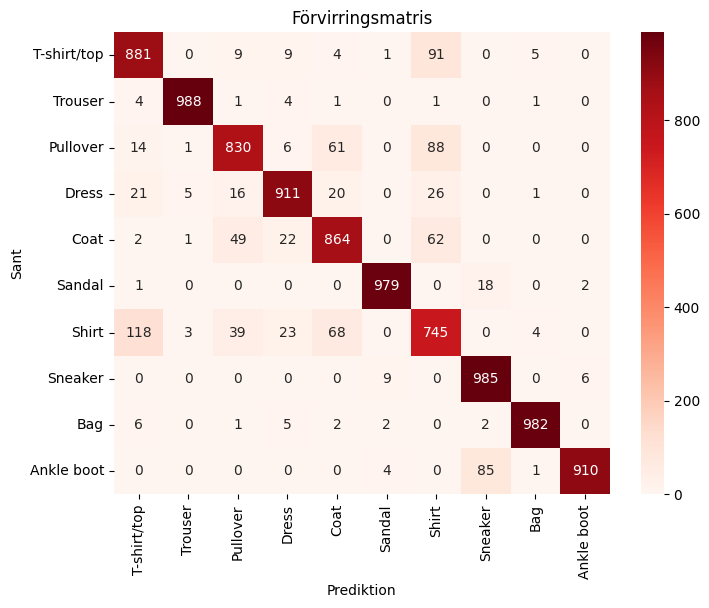


Modellens prestanda: klassificeringsrapport..
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.88      0.86      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.88      0.83      0.85      1000
       Dress       0.93      0.91      0.92      1000
        Coat       0.85      0.86      0.86      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.74      0.74      0.74      1000
     Sneaker       0.90      0.98      0.94      1000
         Bag       0.99      0.98      0.98      1000
  Ankle boot       0.99      0.91      0.95      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

Antal felklassificerade exempel: 925


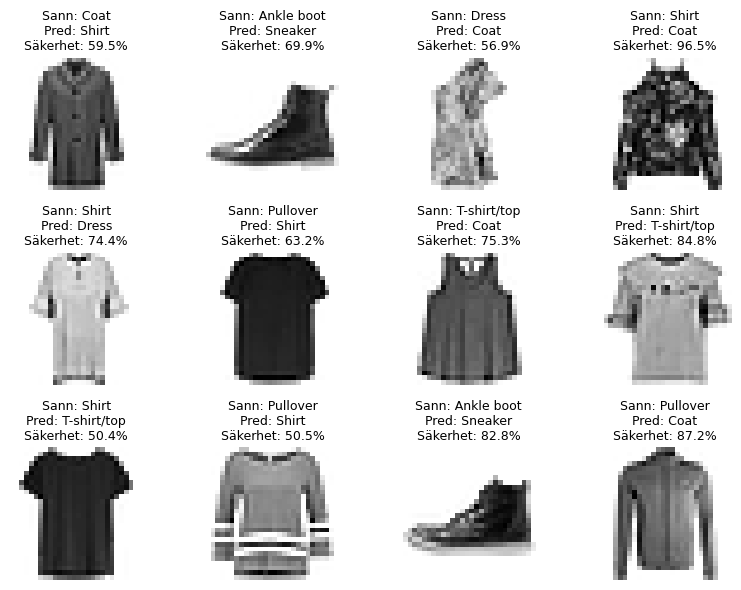

In [9]:
# Ta bästa model och gör prediktioner på X_test
best_model_name = results_df.iloc[0]["Modell"]
best_batch_model = models[best_model_name]

y_pred_proba = best_batch_model.predict(X_test)
# Låt argmax göra högsta sannolikhet till = modellens gissad klass (0-9)
y_pred = np.argmax(y_pred_proba, axis=1)

# Förvirringsmatris och plot
cm = confusion_matrix(y_test_raw, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, cmap='Reds', fmt=',.0f', annot=True,
            xticklabels=class_names, yticklabels=class_names)
plt.title("Förvirringsmatris")
plt.ylabel("Sant")
plt.xlabel("Prediktion")
plt.show()

print("\nModellens prestanda: klassificeringsrapport..")
print(classification_report(y_test_raw, y_pred, target_names=class_names))


# Felklassade bilder och plot
error_indices = np.where(y_test_raw != y_pred)[0]
print(f"Antal felklassificerade exempel: {len(error_indices)}")

if len(error_indices) == 0:
    print("Inga felklassificerade exempel att visa.")

else:
    rng = np.random.default_rng(42)

    chosen_indices = rng.choice(
        error_indices,
        size=min(12, len(error_indices)),
        replace=False
    )

    cols = 4
    rows = int(np.ceil(len(chosen_indices) / cols))
    plt.figure(figsize=(8, 2 * rows))

    for plot_index, data_index in enumerate(chosen_indices):
        true_label = y_test_raw[data_index]
        pred_label = y_pred[data_index]

        confidence = y_pred_proba[data_index, pred_label] * 100

        plt.subplot(rows, cols, plot_index + 1)
        plt.imshow(X_test[data_index].squeeze(), cmap="binary")
        plt.title(
            f"Sann: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]}\n"
            f"Säkerhet: {confidence:.1f}%",
            fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

Modellen gav accuracy $90\%$, för det var 994 fel av 10 000 exempel.

Kläderna klassas med bra F1 och accuracy förutom Shirt, svagaste klassen $F1=0.74$. Pixlarna 28×28 kan ha som varför att Shirt, T-shirt och Pullover ser liknande ut, kolla plot (bilder) med vanliga felen.

Att klädernas bilder har dålig kvalitet/storlek kan förklara mer av felklassningar, inte på grund av dålig modell-träning.

## 8. Fördjupning i batch

Olika storlekar på batch gav olika stabiliteter, så vad orsakar bruset? Läsning i *StackOverflow* och *Chicken Counting* går in på:
* Loss per batch,
* Log interval,
* GPU memory.

Källor:
* https://stackoverflow.com/questions/65383500/tensorflow-keras-keep-loss-of-every-batch
* https://colab.research.google.com/github/IOAI-official/IOAI-2025/blob/main/Individual-Contest/Chicken_Counting/Chicken_Counting.ipynb#scrollTo=tmRcqrjPBg4z

Text(0, 0.5, 'Loss')

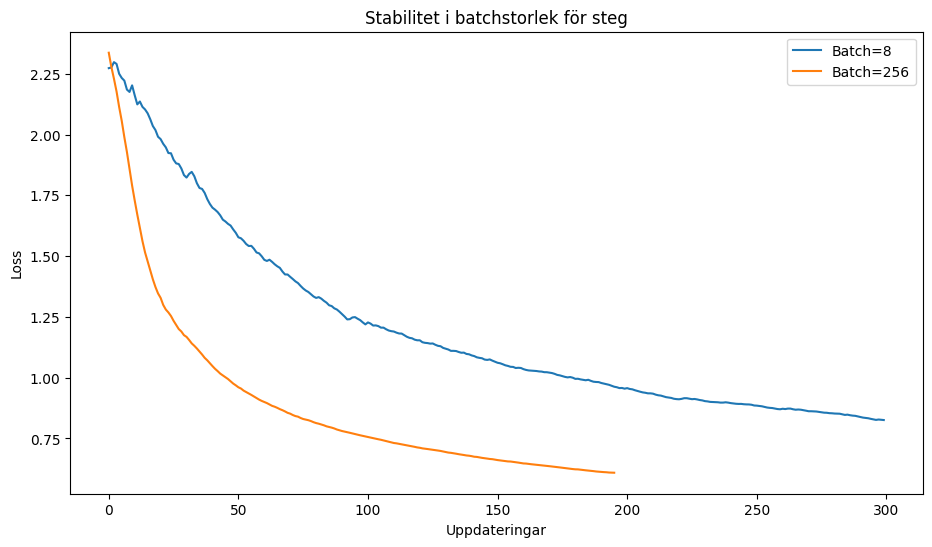

In [10]:
class BatchLossLogger(tf.keras.callbacks.Callback):
  # Gör en Logger för att behålla Loss efter varje batch sekvens
  def on_train_begin(self, logs=None):
    self.batch_losses = []

  def on_train_batch_end(self, batch, logs=None):
    self.batch_losses.append(logs['loss'])

# Skapa klass-instanser
logger_batch8 = BatchLossLogger()
logger_batch256 = BatchLossLogger()

# Gör tillfälliga modeller som tränas och så sparas loss i loggers
model_maker().fit(X_train, y_train, epochs=1, batch_size=8, callbacks=[logger_batch8], verbose=0)
model_maker().fit(X_train, y_train, epochs=1, batch_size=256, callbacks=[logger_batch256], verbose=0)

# Graf för logger small & large
plt.figure(figsize=(11,6))
plt.plot(logger_batch8.batch_losses[:300], label='Batch=8')
plt.plot(logger_batch256.batch_losses[:300], label='Batch=256')
plt.legend()
plt.title("Stabilitet i batchstorlek för steg")
plt.xlabel("Uppdateringar")
plt.ylabel("Loss")

Med lilla batchstorleken á 8 görs många mer uppdateringar än för batch 256 så det visas i ploten. Via datasetets storlek fås att Batch 8 gör 6,250 updates per epok och Batch 256 gör mycket färre: 195.

Gradient updates för Batch 256 behandlar större antal bilder och får mer pålitligt genomsnitt med snabb konvergens, och för Batch 8 konvergerar långsamt men bruset är synligare som positivt sett kan göra så lösningen inte fastnar i lokala minimum.

## Nästa fördjupning går in på accuracy per sekund

Batch=Batch_32 time at end: 90.8
Batch=Batch_64 time at end: 61.5
Batch=Batch_128 time at end: 54.1


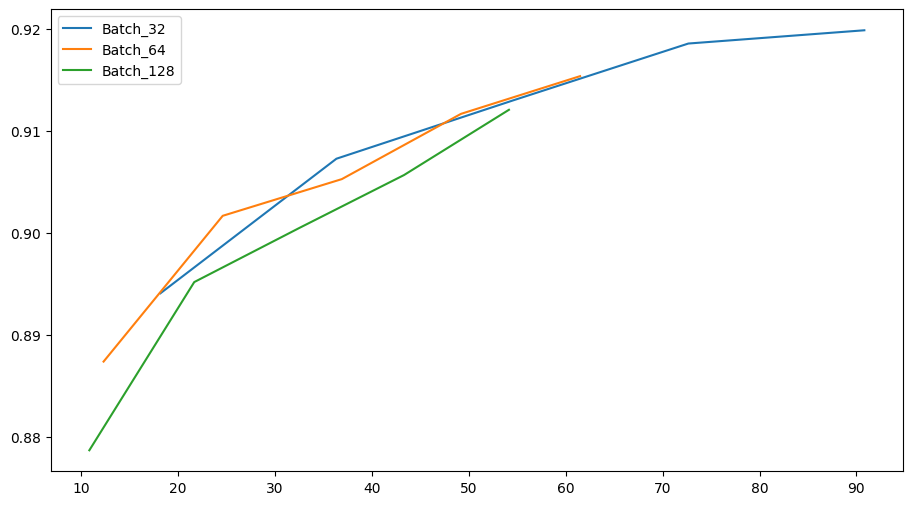

In [11]:
plt.figure(figsize=(11,6))

for _ in histories:
  total_time = times[_]
  accuracies = histories[_].history['val_accuracy']
  length = len(accuracies)
  time_per_update = total_time/length
  seconds = [time_per_update*i for i in range(1,length+1)]
  plt.plot(seconds, accuracies, label=f"{_}")
  print(f"Batch={_} time at end: {round(total_time,1)}")
plt.legend()
plt.show()

Ju flera läsningar det är desto mer tid tar modell med mindre batch size att starta och göra klart.

Större batchstorlek går igång och avslutar fortare än liten batchstorlek.

Högst accuracy är fått från balanserad modell emot convergence, stabilitet och hårdvaraanvändning.

Batch 64 konvergerar fortare än Batch 32 men ungefär samma sista accuracy.



## 9. Diskussion

**Vi lärde oss:**
* Batchstorlek samt epoker påverkar modellträning.
* Epoker handlar om antalet gånger som modellträning görs, fler epoker garanterar inte bättre resultat.
* Validerings accuracy blev snabbt horisontell fast träningsaccuracy steg som pekar på overfitting (generalisering slutar och träningsdatan blir inlärd istället).
* Batchstorlek påverkar sättet modellen lär sig via antalet uppdateringar (som beror på storlek) och brus per steg. Träningstid per batch size, per epok (kap 6) och accuracy per sekund (kap 9) visar på balansning mellan tid för convergence, stabilitet och hårdvaraanvändning.

**Största påverkning** kom synligt från epoker när ökande skillnad mellan train och validering som handla om overfitting.

**Begränsningar**:
* Vi hade fastställd modellarkitektur, så andra strukturer kan ha skillnader vart overfitting kommer eller bästa batchstorleken.
* Datasetet är små och lågkvalitativa bilder så våra observerade effekter kanske är större med annan data.

**Fortsättning** är att regularisera med dropout, L2 eller early stop. Testa även andra optimerare och arkitektur, och augmentera datan.